Tensorflow version 2.15.0
Built-in Keras version (same as TF): 2.15.0
训练集形状: (60000, 28, 28)
Class label is: 4
Class name is: 4


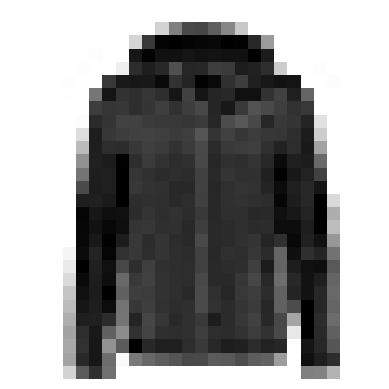

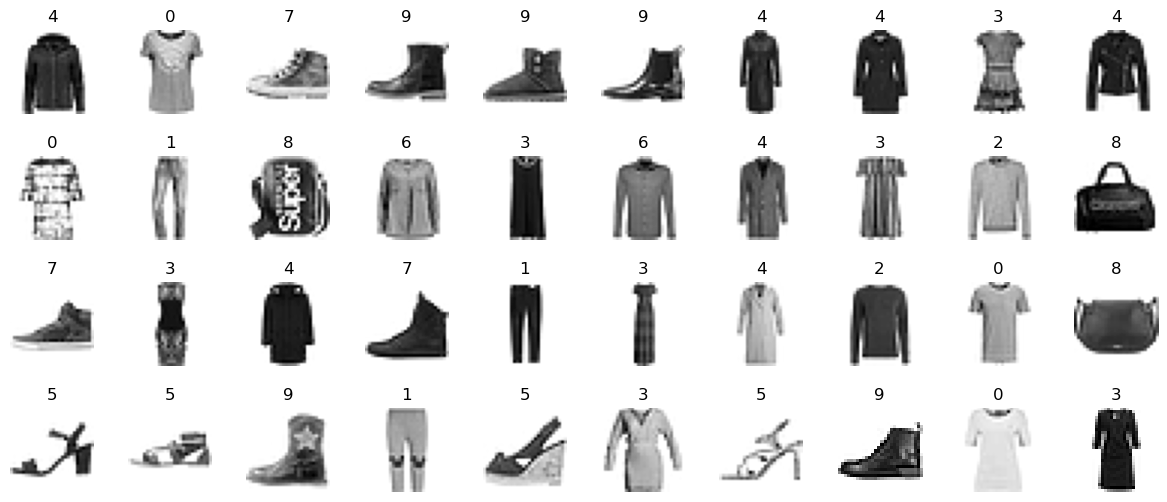


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.
Ep

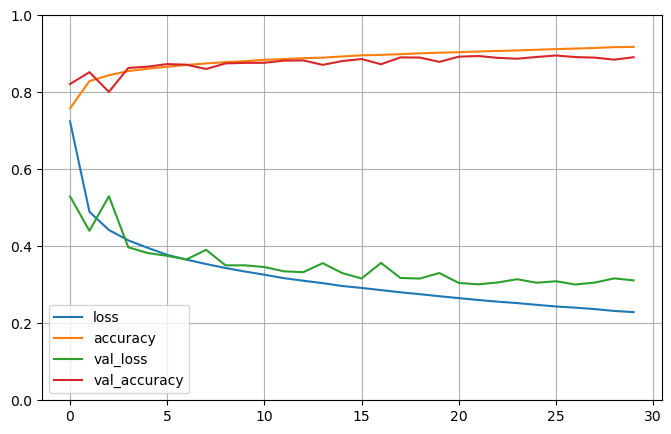

313/313 [==============================] - 0s 1ms/step - loss: 0.3432 - accuracy: 0.8782
测试集评估结果: [0.3432285785675049, 0.8781999945640564]
1/1 [==============================] - 0s 88ms/step
预测标签: [9 2 1]
预测类别名称: ['9', '2', '1']


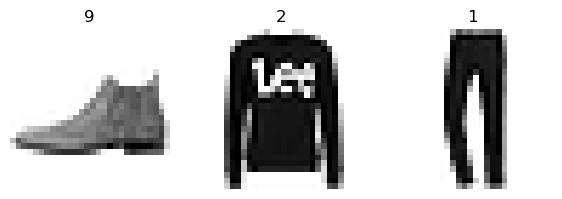

In [2]:
# 导入必要库
import numpy as np
import tensorflow as tf
print("Tensorflow version", tf.__version__)
from tensorflow import keras
print("Built-in Keras version (same as TF):", tf.__version__)
import matplotlib.pyplot as plt
import gzip
import os

# 设置随机种子保证可复现
np.random.seed(42) 
tf.random.set_seed(42)

# ----------------------
# 1. 定义本地MNIST文件路径
# ----------------------
# 请根据你的实际文件存放位置修改下面的路径！
data_dir = "D:\code\C++\pyu\\"  # 假设这四个文件都放在当前目录下
train_images_path = os.path.join(data_dir, "train-images-idx3-ubyte.gz")
train_labels_path = os.path.join(data_dir, "train-labels-idx1-ubyte.gz")
test_images_path = os.path.join(data_dir, "t10k-images-idx3-ubyte.gz")
test_labels_path = os.path.join(data_dir, "t10k-labels-idx1-ubyte.gz")

# ----------------------
# 2. 读取idx格式数据的工具函数
# ----------------------
def load_images(path):
    with gzip.open(path, 'rb') as f:
        # 读取文件头
        magic = int.from_bytes(f.read(4), byteorder='big')
        num_images = int.from_bytes(f.read(4), byteorder='big')
        rows = int.from_bytes(f.read(4), byteorder='big')
        cols = int.from_bytes(f.read(4), byteorder='big')
        # 读取像素数据并转为numpy数组
        buf = f.read(num_images * rows * cols)
        data = np.frombuffer(buf, dtype=np.uint8)
        data = data.reshape(num_images, rows, cols)
        return data

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        # 读取文件头
        magic = int.from_bytes(f.read(4), byteorder='big')
        num_labels = int.from_bytes(f.read(4), byteorder='big')
        # 读取标签数据并转为numpy数组
        buf = f.read(num_labels)
        data = np.frombuffer(buf, dtype=np.uint8)
        return data

# ----------------------
# 3. 加载并预处理MNIST数据
# ----------------------
X_train_full = load_images(train_images_path)
y_train_full = load_labels(train_labels_path)
X_test = load_images(test_images_path)
y_test = load_labels(test_labels_path)

print("训练集形状:", X_train_full.shape)

# 划分训练集和验证集
X_valid = X_train_full[:5000] / 255.0
X_train = X_train_full[5000:] / 255.0

y_valid = y_train_full[:5000] 
y_train = y_train_full[5000:]

# 测试集归一化
X_test = X_test / 255.0

# MNIST手写数字的类别（0-9）
class_names = [str(i) for i in range(10)]

# ----------------------
# 4. 可视化数据集（和原代码逻辑保持一致）
# ----------------------
print("Class label is:", y_train[0])
print("Class name is:", class_names[y_train[0]])
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

n_rows = 4
n_cols = 10
plt.figure(figsize=(15, 6))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary")
        plt.axis('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

# ----------------------
# 5. 构建模型（和原代码结构一致，适配28x28输入）
# ----------------------
keras.backend.clear_session()

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()

# 绘制模型结构图（可选，如无graphviz可注释掉）
try:
    keras.utils.plot_model(model, "my_mnist_model.png", show_shapes=True)
except Exception as e:
    print("模型结构图绘制失败（可能缺少graphviz），可忽略此步骤")

# ----------------------
# 6. 编译并训练模型
# ----------------------
sgd = keras.optimizers.SGD(learning_rate=0.01)

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=sgd,
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

print(history.params)

# 查看隐藏层权重
hidden1 = model.layers[1]
print(hidden1.name)
weights, biases = hidden1.get_weights()
print("权重形状:", weights.shape)
print("偏置形状:", biases.shape)

# ----------------------
# 7. 训练过程可视化
# ----------------------
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

# ----------------------
# 8. 模型评估与预测
# ----------------------
print("测试集评估结果:", model.evaluate(X_test, y_test))

y_proba = model.predict(X_test[:3])
y_pred = np.argmax(y_proba, axis=1)
print("预测标签:", y_pred)
print("预测类别名称:", [class_names[index] for index in y_pred])

plt.figure(figsize=(7, 3))
for index, image in enumerate(X_test[:3]):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary")
    plt.axis('off')
    plt.title(class_names[y_pred[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()